# The Mathematics Behind Quantum Computing

This notebook is a companion to our first tutorial on quantum computing. It starts from the same ideas—qubits, measurement, Hadamard gates, Bell pairs, interference, sampling, noise, and algorithms—and derives the mathematics that makes them work.

We will use complex vectors for states, matrices for gates, squared amplitudes for probabilities, and tensor products for registers. Small NumPy calculations make each claim checkable without requiring a quantum device.

## Learning path

1. State vectors, complex amplitudes, and normalization
2. Measurement and the Born rule
3. Unitary gates, phase, and interference
4. Tensor products, Bell states, and entanglement
5. Sampling, Grover amplification, and phase kickback
6. Density matrices, noise, and quantum time evolution

## 1. A qubit is a normalized vector

Choose the computational basis vectors

$$|0\rangle = \begin{bmatrix}1\\0\end{bmatrix}, \qquad |1\rangle = \begin{bmatrix}0\\1\end{bmatrix}.$$

A pure qubit state is a linear combination of these basis states:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{bmatrix}\alpha\\\beta\end{bmatrix}, \qquad \alpha,\beta \in \mathbb{C}.$$

The complex numbers $\alpha$ and $\beta$ are **amplitudes**. A physical state is normalized, meaning its squared magnitudes sum to one: $|\alpha|^2 + |\beta|^2 = 1$. The complex conjugate transpose is written $\langle\psi|$, and the inner product $\langle\psi|\psi\rangle$ is the squared length of the vector.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

def norm_squared(state):
    return float(np.vdot(state, state).real)

def probabilities(state):
    return np.abs(state) ** 2

plus = (ket0 + ket1) / np.sqrt(2)
print(
"|+> state:"
, plus)
print(
"squared norm:"
, norm_squared(plus))

|+> state: [0.70710678+0.j 0.70710678+0.j]
squared norm: 0.9999999999999998


A useful subtlety: multiplying every amplitude by the same complex number of magnitude one, such as $e^{i\phi}$, changes no measurement statistics. This is called a **global phase**, and it does not describe a physically distinguishable state. A **relative phase** between amplitudes can affect later measurements, so it matters. The next sections make that difference visible.

## 2. Measurement: the Born rule

When a qubit is measured in the computational basis, the probability of outcome 0 is $|\alpha|^2$ and the probability of outcome 1 is $|\beta|^2$. This is the **Born rule**. One run returns one classical bit; the amplitudes determine the distribution across many identical runs.

For a state vector $|\psi\rangle$ and basis state $|j\rangle$, the outcome probability is $|\langle j|\psi\rangle|^2$. More generally, if $P_j$ projects onto an outcome subspace, then $p(j)=\langle\psi|P_j|\psi\rangle$.

In [2]:
state = np.array([1, 1j], dtype=complex) / np.sqrt(2)
outcome_probabilities = probabilities(state)
print(
"amplitudes:"
, state)
print(
"probabilities for 0 and 1:"
, outcome_probabilities)
assert np.isclose(outcome_probabilities.sum(), 1)

amplitudes: [0.70710678+0.j         0.        +0.70710678j]
probabilities for 0 and 1: [0.5 0.5]


### Repeated shots are samples

A simulator or device returns counts because each shot is one sample from the Born-rule distribution. If outcome 1 has probability $p$, then after $N$ independent shots its observed fraction has standard deviation $\sqrt{p(1-p)/N}$. The typical sampling error therefore falls like $1/\sqrt{N}$, but the estimate is not guaranteed to become exactly equal to $p$.

   10 shots: estimated P(1) = 0.600
  100 shots: estimated P(1) = 0.510
 1000 shots: estimated P(1) = 0.493
10000 shots: estimated P(1) = 0.503


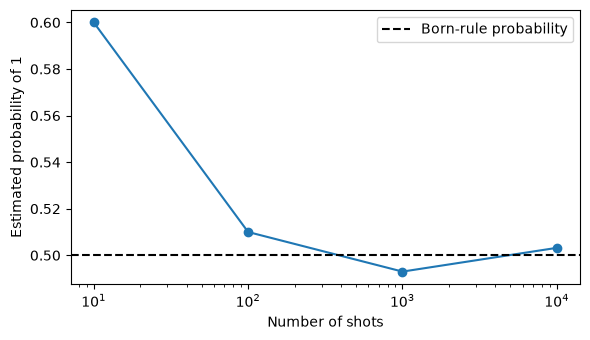

In [3]:
rng = np.random.default_rng(7)
probability_one = outcome_probabilities[1]
shot_counts = [10, 100, 1000, 10000]
estimates = []
for shots in shot_counts:
    samples = rng.choice([0, 1], size=shots, p=outcome_probabilities)
    estimates.append(samples.mean())
    print(f"{shots:>5} shots: estimated P(1) = {samples.mean():.3f}")

figure, axis = plt.subplots(figsize=(6, 3.5))
axis.plot(shot_counts, estimates, marker="o")
axis.axhline(probability_one, color="black", linestyle="--", label="Born-rule probability")
axis.set_xscale("log")
axis.set_xlabel("Number of shots")
axis.set_ylabel("Estimated probability of 1")
axis.legend()
figure.tight_layout()
plt.show()

## 3. Gates are unitary transformations

A quantum gate maps one state vector to another: $|\psi'\rangle=U|\psi\rangle$. To preserve total probability for every input, its matrix must be **unitary**: $U^\dagger U=I$, where $U^\dagger$ is the conjugate transpose. Unitarity means the transformation is reversible; its inverse is $U^\dagger$.

Two basic gates are the bit flip $X$ and the Hadamard $H$:

$$X=\begin{bmatrix}0&1\\1&0\end{bmatrix}, \qquad H=\frac{1}{\sqrt{2}}\begin{bmatrix}1&1\\1&-1\end{bmatrix}.$$

The columns of a gate matrix are the output states for its basis-state inputs. In particular, $H|0\rangle=|+\rangle$ and $H|1\rangle=| - \rangle=(|0\rangle-|1\rangle)/\sqrt{2}$.

In [4]:
identity = np.eye(2, dtype=complex)
x_gate = np.array([[0, 1], [1, 0]], dtype=complex)
h_gate = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

for name, gate in [("X", x_gate), ("H", h_gate)]:
    print(f"{name}^dagger {name} =\n{gate.conj().T @ gate}\n")
    assert np.allclose(gate.conj().T @ gate, identity)

print("H|0> =", h_gate @ ket0)
print("H|1> =", h_gate @ ket1)

X^dagger X =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

H^dagger H =
[[ 1.00000000e+00+0.j -2.23711432e-17+0.j]
 [-2.23711432e-17+0.j  1.00000000e+00+0.j]]

H|0> = [0.70710678+0.j 0.70710678+0.j]
H|1> = [ 0.70710678+0.j -0.70710678+0.j]


### Relative phase becomes interference

The states $|+\rangle=(|0\rangle+|1\rangle)/\sqrt{2}$ and $| - \rangle=(|0\rangle-|1\rangle)/\sqrt{2}$ both give 50/50 results if measured immediately in the computational basis. But applying $H$ again gives different answers: $H|+\rangle=|0\rangle$, while $H| - \rangle=|1\rangle$. The minus sign does not change the first measurement probabilities, but it changes how amplitudes add under a later gate.

This addition and cancellation of amplitudes is **interference**. Probabilities are computed after amplitudes have combined; adding probabilities at each intermediate step would lose the phase information.

In [5]:
minus = (ket0 - ket1) / np.sqrt(2)
for name, state_vector in [("plus", plus), ("minus", minus)]:
    print(f"{name}: before H {probabilities(state_vector)}, after H {probabilities(h_gate @ state_vector)}")

assert np.allclose(probabilities(h_gate @ plus), [1, 0])
assert np.allclose(probabilities(h_gate @ minus), [0, 1])

plus: before H [0.5 0.5], after H [1.00000000e+00 5.00468047e-34]
minus: before H [0.5 0.5], after H [5.00468047e-34 1.00000000e+00]


## 4. Registers use tensor products

For two qubits, the joint basis has four states: $|00\rangle, |01\rangle, |10\rangle, |11\rangle$. A product state is built with the tensor (Kronecker) product, for example $|a\rangle\otimes|b\rangle$. A general two-qubit state has four complex amplitudes; an $n$-qubit state has $2^n$ amplitudes.

**Qiskit ordering note:** the statevector basis is indexed as $|q_{n-1}\cdots q_1q_0\rangle$, so qubit 0 is the rightmost bit. We will write two-qubit vectors in the order $|q_1q_0\rangle$. Thus $|q_1\rangle\otimes|q_0\rangle$ is represented by `np.kron(q1, q0)`.

In [6]:
two_qubit_00 = np.kron(ket0, ket0)
two_qubit_01 = np.kron(ket0, ket1)
print("|00> =", two_qubit_00)
print("|01> =", two_qubit_01)

h_on_q0 = np.kron(identity, h_gate)
print("H on q0 acting on |00> =", h_on_q0 @ two_qubit_00)

|00> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|01> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
H on q0 acting on |00> = [0.70710678+0.j 0.70710678+0.j 0.        +0.j 0.        +0.j]


### The Bell pair, derived

The initial tutorial's Bell-state circuit applies $H$ to qubit 0 and then a controlled-NOT (CNOT), with qubit 0 as control and qubit 1 as target. Starting from $|00\rangle$:

$$|00\rangle \xrightarrow{H_0} \frac{|00\rangle+|01\rangle}{\sqrt{2}} \xrightarrow{\mathrm{CNOT}_{0\to1}} \frac{|00\rangle+|11\rangle}{\sqrt{2}}.$$

CNOT flips the target exactly when the control is 1. In the chosen basis ordering, its matrix permutes $|01\rangle$ and $|11\rangle$.

In [7]:
cnot_control_q0 = np.array([[1, 0, 0, 0],
                            [0, 0, 0, 1],
                            [0, 0, 1, 0],
                            [0, 1, 0, 0]], dtype=complex)
bell = cnot_control_q0 @ (h_on_q0 @ two_qubit_00)
print("Bell state amplitudes in |00>, |01>, |10>, |11> order:", bell)
print("measurement probabilities:", probabilities(bell))
assert np.allclose(bell, [1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)])

Bell state amplitudes in |00>, |01>, |10>, |11> order: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
measurement probabilities: [0.5 0.  0.  0.5]


The Bell state produces only `00` or `11` on measurement, each with probability one half. Its individual qubits each look random, but their results are perfectly correlated. More strongly, this state cannot be written as $|a\rangle\otimes|b\rangle$; it is **entangled**. Correlation alone is not the definition of entanglement: the mathematical test is whether the joint state factors into separate subsystem states.

For a pure two-qubit state, reshape its amplitudes into a $2\times2$ matrix. The state is a product state exactly when that matrix has rank one. A related perspective uses the reduced density matrix: tracing out either qubit of a Bell pair gives $I/2$, a maximally mixed state.

In [8]:
amplitude_matrix = bell.reshape(2, 2)
reduced_q0 = amplitude_matrix.conj().T @ amplitude_matrix
print("amplitude-matrix rank:", np.linalg.matrix_rank(amplitude_matrix))
print("reduced state of q0:\n", reduced_q0)
assert np.allclose(reduced_q0, np.eye(2) / 2)

amplitude-matrix rank: 2
reduced state of q0:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


## 5. Amplitude amplification: a two-qubit Grover step

With two qubits, an equal superposition has amplitude $1/2$ for each of four answers. An oracle marks answer `11` by changing only its amplitude's sign. The **diffuser** reflects the amplitudes about their average: as a matrix, $D=2|s\rangle\langle s|-I$, where $|s\rangle$ is the uniform state. The marked amplitude becomes large, while the others cancel.

This is the same interference principle as the Hadamard example, applied to a search problem. For four items and one marked answer, a single Grover iteration is enough to make the marked outcome certain in the ideal mathematical model.

In [9]:
uniform = np.ones(4, dtype=complex) / 2
oracle = np.diag([1, 1, 1, -1]).astype(complex)
diffuser = 2 * np.outer(uniform, uniform.conj()) - np.eye(4)
grover_state = diffuser @ oracle @ uniform
print("amplitudes [00, 01, 10, 11]:", grover_state)
print("probabilities:", probabilities(grover_state))
assert np.allclose(probabilities(grover_state), [0, 0, 0, 1])

amplitudes [00, 01, 10, 11]: [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
probabilities: [0. 0. 0. 1.]


### Phase kickback and Deutsch-Jozsa

A function oracle can compute $|x,y\rangle\mapsto|x,y\oplus f(x)\rangle$. If its helper qubit is prepared in $| - \rangle=(|0\rangle-|1\rangle)/\sqrt{2}$, flipping that helper contributes a factor $(-1)^{f(x)}$ while leaving it in the same state. The function value has been written into the **phase** of the input amplitude; this is phase kickback.

For one input bit, after the final Hadamard, the amplitude of outcome 0 is $\frac{1}{2}\sum_{x\in\{0,1\}}(-1)^{f(x)}$. A constant function makes this sum nonzero, while a balanced function makes it cancel to zero. This is the algebra behind the one-bit Deutsch-Jozsa example.

In [10]:
def one_bit_dj_probabilities(function_values):
    phase_state = np.array([(-1) ** value for value in function_values], dtype=complex) / np.sqrt(2)
    return probabilities(h_gate @ phase_state)

print("constant f(x)=0, probabilities [0, 1]:", one_bit_dj_probabilities([0, 0]))
print("balanced f(x)=x, probabilities [0, 1]:", one_bit_dj_probabilities([0, 1]))
assert np.allclose(one_bit_dj_probabilities([0, 0]), [1, 0])
assert np.allclose(one_bit_dj_probabilities([0, 1]), [0, 1])

constant f(x)=0, probabilities [0, 1]: [1.00000000e+00 5.00468047e-34]
balanced f(x)=x, probabilities [0, 1]: [5.00468047e-34 1.00000000e+00]


## 6. Density matrices describe mixtures and noise

A state vector describes a pure state. A **density matrix** $\rho$ also represents statistical mixtures and lets us model how noise removes coherence. For a pure state, $\rho=|\psi\rangle\langle\psi|$. Measurement probabilities are $p(j)=\mathrm{Tr}(P_j\rho)$, and a unitary gate updates the state as $\rho'=U\rho U^\dagger$.

Consider $|+\rangle$. Its density matrix has diagonal entries $1/2$ and off-diagonal entries $1/2$. Phase damping can shrink those off-diagonal terms while leaving the computational-basis probabilities unchanged. The lost coherence becomes visible if we apply a Hadamard and measure in a different basis.

In [11]:
plus_density = np.outer(plus, plus.conj())
print("density matrix of |+>:\n", plus_density)

for coherence in [1.0, 0.5, 0.0]:
    noisy_density = np.array([[0.5, coherence / 2], [coherence / 2, 0.5]], dtype=complex)
    after_hadamard = h_gate @ noisy_density @ h_gate.conj().T
    print(f"coherence={coherence:.1f}: Z probabilities={np.diag(noisy_density).real}, after H={np.diag(after_hadamard).real}")

density matrix of |+>:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
coherence=1.0: Z probabilities=[0.5 0.5], after H=[1. 0.]
coherence=0.5: Z probabilities=[0.5 0.5], after H=[0.75 0.25]
coherence=0.0: Z probabilities=[0.5 0.5], after H=[0.5 0.5]


## 7. Gates as time evolution

In quantum mechanics, a system with Hamiltonian $H$ evolves for time $t$ by the unitary $U(t)=e^{-iHt/\hbar}$. A gate is therefore not only a matrix in a circuit; it can also represent a controlled interval of physical evolution.

For a qubit with $H=\frac{\hbar\omega}{2}Y$, where $Y$ is the Pauli-$Y$ matrix, $U(t)$ is the rotation $R_Y(\omega t)$. Starting from $|0\rangle$, the probability of measuring 1 is $\sin^2(\omega t/2)$. This is the same sinusoidal law used in the tutorial's qubit-simulation example.

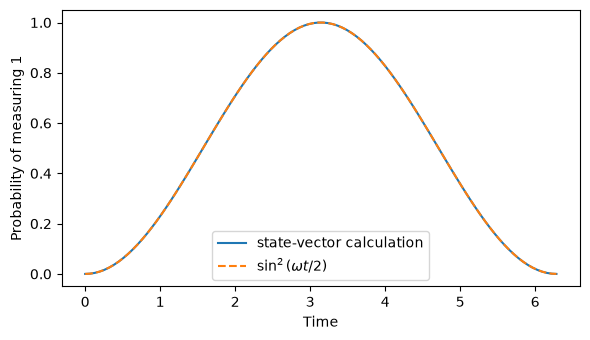

In [12]:
omega = 1.0
times = np.linspace(0, 2 * np.pi, 100)
angles = omega * times
ry_states = np.array([
    [np.cos(angle / 2), np.sin(angle / 2)]
    for angle in angles
])
simulated_probability = np.abs(ry_states[:, 1]) ** 2
exact_probability = np.sin(omega * times / 2) ** 2

figure, axis = plt.subplots(figsize=(6, 3.5))
axis.plot(times, simulated_probability, label="state-vector calculation")
axis.plot(times, exact_probability, linestyle="--", label=r"$\sin^2(\omega t/2)$")
axis.set_xlabel("Time")
axis.set_ylabel("Probability of measuring 1")
axis.legend()
figure.tight_layout()
plt.show()
assert np.allclose(simulated_probability, exact_probability)

## 8. A larger state space is not automatic speedup

An $n$-qubit pure state has $2^n$ amplitudes, but measurement returns only one classical outcome per shot. A quantum algorithm must choose gates so that interference makes useful answers likely, and it must do so with a circuit that is feasible under noise and hardware constraints. Superposition alone does not let us read out every amplitude.

This explains the connection to the original tutorial's examples: Grover uses amplitude amplification for unstructured search; Deutsch-Jozsa engineers cancellation to learn a promised property; Shor uses period-finding and the quantum Fourier transform. They are different algorithms built from the same linear-algebra rules, and their advantages apply to particular problem structures rather than every computation.

In [13]:
for qubits in [1, 5, 10, 20, 30]:
    print(f"{qubits:>2} qubits: {2 ** qubits:>12,} complex amplitudes in a general state vector")

 1 qubits:            2 complex amplitudes in a general state vector
 5 qubits:           32 complex amplitudes in a general state vector
10 qubits:        1,024 complex amplitudes in a general state vector
20 qubits:    1,048,576 complex amplitudes in a general state vector
30 qubits: 1,073,741,824 complex amplitudes in a general state vector


## Try It

1. Replace `state` with $(\sqrt{3}/2)|0\rangle+(1/2)|1\rangle$. Compute its measurement probabilities and confirm normalization.
2. Apply $X$ and then $H$ to $|0\rangle$. What are the final probabilities?
3. Change the Bell circuit's first gate from $H$ to $X$. Is the result entangled? Explain using whether its amplitude matrix has rank one.
4. In the Grover example, change which basis state the oracle marks. Does the same diffuser amplify it?
5. Set the phase-damping coherence to 0.25. Compare measurement in the computational basis before and after applying $H$.
6. Explain why increasing shots reduces sampling uncertainty but does not reverse gate noise or readout bias.

## Answers

1. The amplitudes are $\alpha=\sqrt{3}/2$ and $\beta=1/2$. Thus $P(0)=|\alpha|^2=3/4$ and $P(1)=|\beta|^2=1/4$. They sum to 1, confirming normalization.

2. $X|0\rangle=|1\rangle$, then $H|1\rangle=(|0\rangle-|1\rangle)/\sqrt{2}$. Both outcomes therefore have probability $1/2$.

3. Starting at $|00\rangle$, applying $X$ on qubit 0 and then CNOT yields $|11\rangle$. It factors as $|1\rangle\otimes|1\rangle$. Its amplitude matrix has rank 1, so the result is not entangled.

4. Yes. The uniform state and diffuser are symmetric across basis states. Marking any one basis state with a phase flip and applying the same diffuser amplifies that marked state; for four states, one ideal Grover iteration makes its probability 1.

5. At coherence $c=0.25$, $\rho=\begin{bmatrix}0.5&0.125\\0.125&0.5\end{bmatrix}$. Before $H$, the computational-basis probabilities are $(0.5,0.5)$. After $H$, they are $(0.5+c/2,0.5-c/2)=(0.625,0.375)$.

6. Sampling uncertainty typically falls as $1/\sqrt{N}$ with $N$ shots. More shots make the estimated distribution more precise, but gate errors alter the state and readout bias alters reported outcomes. Repetition does not undo either systematic error.

## Summary

A quantum computation is a sequence of unitary transformations on normalized complex vectors, followed by measurement governed by the Born rule. Tensor products describe registers; entanglement is non-factorability; relative phase controls interference; density matrices describe mixtures and decoherence. Quantum algorithms use these rules to shape measurement distributions, not to expose all amplitudes at once.